# Genomic Prediction using SNP Data and Machine Learning

#This project demonstrates how machine learning can be used to predict a trait from SNP (genomic) data and identify important genetic markers.

## Objectives
- Simulate SNP data
- Train a machine learning model
- Predict trait values
- Identify important SNPs

In [19]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 1000
n_snps = 300

X = np.random.randint(0, 3, size=(n_samples, n_snps))

true_snps = np.random.choice(n_snps, 10)

y = X[:, true_snps].sum(axis=1) + np.random.normal(0, 0.1, n_samples)

df = pd.DataFrame(X, columns=[f"SNP_{i}" for i in range(n_snps)])
df["trait"] = y

./## Data Stimulation

#We simulate SNP data (0,1,2 encoding) and create a trait influenced by a subset of SNPs.

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop("trait", axis=1)
y = df["trait"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

#We train a Random Forest model to predict the trait from SNP data.

In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=300)
max_depth=10
random_state=42
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Results

In [22]:
from sklearn.metrics import r2_score

preds = model.predict(X_test)
print("R2:", r2_score(y_test, preds))

R2: 0.6338782043797206


importance reflects the contribution of each SNP to reducing prediction error in the mode

In [23]:
import pandas as pd

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "SNP": X.columns,
    "importance": importances
})

top_snps = importance_df.sort_values(by="importance", ascending=False).head(10)

print(top_snps)

         SNP  importance
253  SNP_253    0.096931
66    SNP_66    0.079307
31    SNP_31    0.072249
284  SNP_284    0.065637
257  SNP_257    0.064707
89    SNP_89    0.050915
187  SNP_187    0.050891
41    SNP_41    0.045029
146  SNP_146    0.043781
139  SNP_139    0.037201


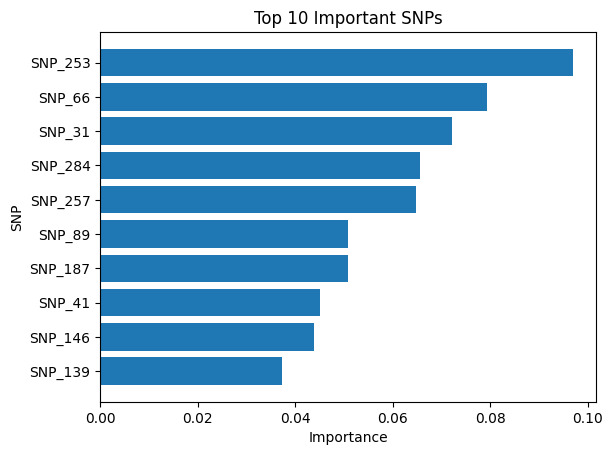

In [24]:
import matplotlib.pyplot as plt

top_snps = importance_df.sort_values(by="importance", ascending=False).head(10)

plt.figure()
plt.barh(top_snps["SNP"], top_snps["importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("SNP")
plt.title("Top 10 Important SNPs")

plt.savefig("snp_importance.png")
plt.show()

In [25]:
# Convert true SNP indices to SNP names (e.g. SNP_10)
true_snp_names = [f"SNP_{i}" for i in true_snps]

# Extracted top predicted SNPs (most important features)
predicted_snps = top_snps["SNP"].tolist()

#Find overlap between true SNPs and predicted SNPs
common_snps = set(true_snp_names) & set(predicted_snps)

print("True SNPs:", true_snp_names)
print("Predicted top SNPs:", predicted_snps)
print("Common SNPs (correctly identified):", common_snps)
print("Number of correctly identified SNPs:", len(common_snps))

True SNPs: ['SNP_139', 'SNP_253', 'SNP_66', 'SNP_41', 'SNP_31', 'SNP_187', 'SNP_146', 'SNP_89', 'SNP_257', 'SNP_284']
Predicted top SNPs: ['SNP_253', 'SNP_66', 'SNP_31', 'SNP_284', 'SNP_257', 'SNP_89', 'SNP_187', 'SNP_41', 'SNP_146', 'SNP_139']
Common SNPs (correctly identified): {'SNP_66', 'SNP_257', 'SNP_139', 'SNP_41', 'SNP_284', 'SNP_31', 'SNP_187', 'SNP_146', 'SNP_89', 'SNP_253'}
Number of correctly identified SNPs: 10


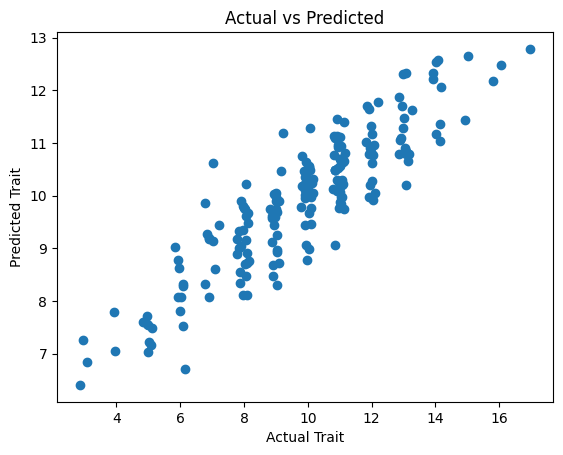

In [26]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, preds)
plt.xlabel("Actual Trait")
plt.ylabel("Predicted Trait")
plt.title("Actual vs Predicted")
plt.savefig("actual_vs_predicted.png")

plt.show()

In [ ]:
## Model Performance Interpretation
The model achieved an R2 score of approximately 0.63, indicating a moderate predictive performance.

The scatter plot of actual vs predicted values shows that predictions closely follow the diagonal trend, indicating that the model successfully captures the relationship between SNPs and the trait.

Some deviation from the line is expected due to noise in the simulated dataset.